In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv('../data/crop_yield.csv')

In [21]:
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [22]:
print('Shape:', df.shape)
print()
print('Columns:', df.columns.tolist())
print()
print('Missing values:')
print(df.isnull().sum())
print()
print(df.head())

Shape: (19689, 10)

Columns: ['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']

Missing values:
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

           Crop  Crop_Year       Season  State     Area  Production  \
0      Arecanut       1997  Whole Year   Assam  73814.0       56708   
1     Arhar/Tur       1997  Kharif       Assam   6637.0        4685   
2   Castor seed       1997  Kharif       Assam    796.0          22   
3      Coconut        1997  Whole Year   Assam  19656.0   126905000   
4  Cotton(lint)       1997  Kharif       Assam   1739.0         794   

   Annual_Rainfall  Fertilizer  Pesticide        Yield  
0           2051.4  7024878.38   22882.34     0.796087  
1           2051.4   631643.29    2057.47     0.710435  
2           20

In [23]:
# Check Season values
print(df['Season'].unique())
print()
print(df['Crop'].nunique(), 'unique crops')
print(df['State'].nunique(), 'unique states')
print()
print('Year range:', df['Crop_Year'].min(), 'to', df['Crop_Year'].max())

['Whole Year ' 'Kharif     ' 'Rabi       ' 'Autumn     ' 'Summer     '
 'Winter     ']

55 unique crops
30 unique states

Year range: 1997 to 2020


In [24]:
# Fix trailing spaces
df['Season'] = df['Season'].str.strip()

# Verify fix
print(df['Season'].unique())

['Whole Year' 'Kharif' 'Rabi' 'Autumn' 'Summer' 'Winter']


Yield stats:
count    19689.000000
mean        79.954009
std        878.306193
min          0.000000
25%          0.600000
50%          1.030000
75%          2.388889
max      21105.000000
Name: Yield, dtype: float64

Skewness: 12.79


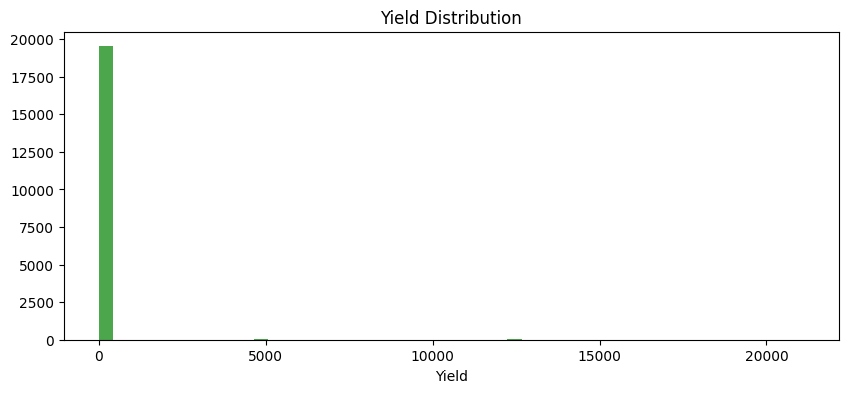

In [25]:
# Understand Yield distribution
print('Yield stats:')
print(df['Yield'].describe())
print()
print('Skewness:', round(df['Yield'].skew(), 2))

# Plot it
plt.figure(figsize=(10, 4))
plt.hist(df['Yield'], bins=50, color='green', alpha=0.7)
plt.title('Yield Distribution')
plt.xlabel('Yield')
plt.show()

In [26]:
# Which crops have highest yield?
print(df.groupby('Crop')['Yield'].mean().sort_values(ascending=False).head(10))
print()

# What are those extreme values?
print('Yield above 1000:')
print(df[df['Yield'] > 1000][['Crop', 'State', 'Yield']].head(10))

Crop
Coconut         8652.000199
Sugarcane         51.727439
Banana            26.851128
Tapioca           16.667301
Potato            13.331718
Onion             13.247525
Sweet potato       9.240788
Jute               7.555393
Ginger             6.442202
Mesta              5.389204
Name: Yield, dtype: float64

Yield above 1000:
         Crop        State         Yield
3    Coconut         Assam   5238.051739
60   Coconut        Kerala   5376.054286
94   Coconut   West Bengal  13003.787780
150  Coconut         Assam   6045.886957
178  Coconut           Goa   4867.650000
195  Coconut     Karnataka   4692.261111
246  Coconut        Kerala   5304.749286
294  Coconut   West Bengal  12448.062220
336  Coconut         Assam   5672.116522
364  Coconut           Goa   4868.070000


Before: (19689, 10)
After removing Coconut: (19517, 10)
Skewness after removing Coconut: 21.57
Skewness after log transform: 1.94


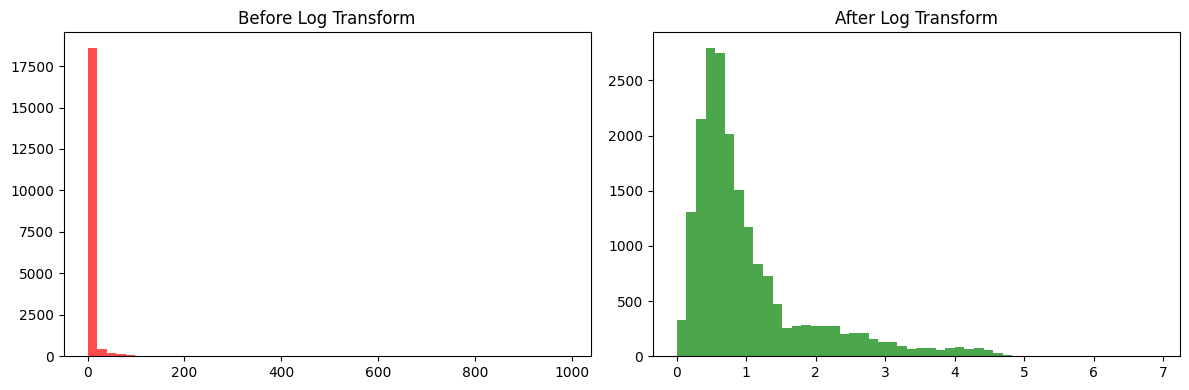

In [27]:
# Step 1 — Remove Coconut (different unit measurement)
print('Before:', df.shape)
df = df[df['Crop'] != 'Coconut ']
print('After removing Coconut:', df.shape)

# Step 2 — Check skewness now
print('Skewness after removing Coconut:', round(df['Yield'].skew(), 2))

# Step 3 — Apply log transform
df['log_yield'] = np.log1p(df['Yield'])
print('Skewness after log transform:', round(df['log_yield'].skew(), 2))

# Step 4 — Plot both
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Yield'], bins=50, color='red', alpha=0.7)
axes[0].set_title('Before Log Transform')
axes[1].hist(df['log_yield'], bins=50, color='green', alpha=0.7)
axes[1].set_title('After Log Transform')
plt.tight_layout()
plt.show()

In [28]:
# Fix the warning — reset index properly
df = df[df['Crop'] != 'Coconut'].copy()
df['log_yield'] = np.log1p(df['Yield'])

print('Shape:', df.shape)
print('Skewness of log_yield:', round(df['log_yield'].skew(), 2))
print()

# Now check — which numeric features correlate with log_yield?
numeric_cols = ['Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'log_yield']
print('Correlation with log_yield:')
print(df[numeric_cols].corr()['log_yield'].sort_values(ascending=False).round(3))


Shape: (19517, 11)
Skewness of log_yield: 1.94

Correlation with log_yield:
log_yield          1.000
Production         0.282
Fertilizer         0.029
Pesticide          0.025
Area               0.023
Annual_Rainfall    0.022
Name: log_yield, dtype: float64


In [29]:
# Create ratio features — these capture efficiency
df['yield_per_area']        = df['Production'] / (df['Area'] + 1)
df['fertilizer_per_area']   = df['Fertilizer'] / (df['Area'] + 1)
df['pesticide_per_area']    = df['Pesticide']  / (df['Area'] + 1)
df['production_per_rain']   = df['Production'] / (df['Annual_Rainfall'] + 1)

# Log transform skewed input features too
df['log_area']        = np.log1p(df['Area'])
df['log_production']  = np.log1p(df['Production'])
df['log_fertilizer']  = np.log1p(df['Fertilizer'])
df['log_pesticide']   = np.log1p(df['Pesticide'])

# Now check correlations again with new features
new_cols = ['log_area', 'log_production', 'log_fertilizer', 'log_pesticide',
            'yield_per_area', 'fertilizer_per_area', 'pesticide_per_area',
            'production_per_rain', 'Annual_Rainfall', 'log_yield']

print('Correlation with log_yield AFTER feature engineering:')
print(df[new_cols].corr()['log_yield'].sort_values(ascending=False).round(3))

Correlation with log_yield AFTER feature engineering:
log_yield              1.000
yield_per_area         0.729
log_production         0.423
production_per_rain    0.255
log_pesticide          0.057
log_fertilizer         0.056
log_area               0.053
fertilizer_per_area    0.047
pesticide_per_area     0.037
Annual_Rainfall        0.022
Name: log_yield, dtype: float64


In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode each categorical column
df['Crop_enc']   = le.fit_transform(df['Crop'])
df['State_enc']  = le.fit_transform(df['State'])
df['Season_enc'] = le.fit_transform(df['Season'])

print('Sample encoding check:')
print(df[['Crop', 'Crop_enc', 'State', 'State_enc', 'Season', 'Season_enc']].head(8))
print()

# Final feature list we will use for modelling
features = ['Crop_enc', 'State_enc', 'Season_enc', 'Crop_Year',
            'log_area', 'log_production', 'log_fertilizer', 'log_pesticide',
            'yield_per_area', 'fertilizer_per_area', 'pesticide_per_area',
            'production_per_rain', 'Annual_Rainfall']

print('Total features:', len(features))
print()
print('Any nulls in features?')
print(df[features].isnull().sum().sum(), 'missing values')

Sample encoding check:
           Crop  Crop_enc  State  State_enc      Season  Season_enc
0      Arecanut         0  Assam          2  Whole Year           4
1     Arhar/Tur         1  Assam          2      Kharif           1
2   Castor seed         8  Assam          2      Kharif           1
4  Cotton(lint)        10  Assam          2      Kharif           1
5  Dry chillies        12  Assam          2  Whole Year           4
6          Gram        15  Assam          2        Rabi           2
7          Jute        20  Assam          2      Kharif           1
8       Linseed        22  Assam          2        Rabi           2

Total features: 13

Any nulls in features?
0 missing values


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Define X and y
X = df[features]
y = df['log_yield']

# Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)
print()

# Train all 4 models
models = {
    'Linear Regression' : LinearRegression(),
    'Lasso'             : Lasso(alpha=0.01),
    'Ridge'             : Ridge(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2   = r2_score(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    results[name] = {'R2': round(r2, 4), 'RMSE': round(rmse, 4)}
    print(f'{name:20s} → R² = {r2:.4f}  |  RMSE = {rmse:.4f}')

Train size: (15613, 13)
Test size : (3904, 13)

Linear Regression    → R² = 0.9303  |  RMSE = 0.2389


c:\Users\smrut\anaconda3\envs\smrutienv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.177e+00, tolerance: 1.168e+00
  model = cd_fast.enet_coordinate_descent(


Lasso                → R² = 0.9311  |  RMSE = 0.2376
Ridge                → R² = 0.9303  |  RMSE = 0.2390
Random Forest        → R² = 0.9904  |  RMSE = 0.0889


In [32]:
# Fix Lasso warning
models['Lasso'] = Lasso(alpha=0.01, max_iter=10000)
models['Lasso'].fit(X_train, y_train)

# Feature importance from Random Forest
rf_model = models['Random Forest']

importance_df = pd.DataFrame({
    'Feature'   : features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('Feature Importances (Random Forest):')
print(importance_df.to_string(index=False))
print()

# Lasso coefficients — which features did it shrink to zero?
lasso_coef = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': models['Lasso'].coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Lasso Coefficients:')
print(lasso_coef.to_string(index=False))

Feature Importances (Random Forest):
            Feature  Importance
     yield_per_area    0.985078
           Crop_enc    0.001790
    Annual_Rainfall    0.001648
          State_enc    0.001567
production_per_rain    0.001410
 pesticide_per_area    0.001327
     log_fertilizer    0.001262
fertilizer_per_area    0.001211
           log_area    0.001124
      log_pesticide    0.001106
         Season_enc    0.001000
     log_production    0.000990
          Crop_Year    0.000488

Lasso Coefficients:
            Feature  Coefficient
     log_production     0.495865
     log_fertilizer    -0.282369
           log_area    -0.210001
         Season_enc     0.035235
     yield_per_area     0.014086
      log_pesticide    -0.008237
fertilizer_per_area     0.001904
          State_enc    -0.001606
          Crop_Year     0.001547
           Crop_enc     0.000803
    Annual_Rainfall    -0.000018
production_per_rain     0.000002
 pesticide_per_area     0.000000


c:\Users\smrut\anaconda3\envs\smrutienv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.541e+00, tolerance: 1.168e+00
  model = cd_fast.enet_coordinate_descent(


In [33]:
# Fix — scale features before Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

models['Lasso'] = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso',  Lasso(alpha=0.01, max_iter=10000))
])
models['Lasso'].fit(X_train, y_train)

preds = models['Lasso'].predict(X_test)
r2   = r2_score(y_test, preds)
rmse = mean_squared_error(y_test, preds) ** 0.5
print(f'Lasso (fixed) → R² = {r2:.4f}  |  RMSE = {rmse:.4f}')

Lasso (fixed) → R² = 0.9294  |  RMSE = 0.2406


In [36]:
# Retrain RF quickly then save everything
from sklearn.ensemble import RandomForestRegressor
import pickle, os

rf_fast = RandomForestRegressor(n_estimators=20, random_state=42, n_jobs=-1)
rf_fast.fit(X_train, y_train)
print('RF retrained ✅')

# Save all models
with open('lr_model.pkl',    'wb') as f: pickle.dump(models['Linear Regression'], f)
with open('lasso_model.pkl', 'wb') as f: pickle.dump(models['Lasso'], f)
with open('ridge_model.pkl', 'wb') as f: pickle.dump(models['Ridge'], f)
with open('rf_model.pkl',    'wb') as f: pickle.dump(rf_fast, f)

# Save label encoders
from sklearn.preprocessing import LabelEncoder
le_crop   = LabelEncoder().fit(df['Crop'])
le_state  = LabelEncoder().fit(df['State'])
le_season = LabelEncoder().fit(df['Season'])

with open('le_crop.pkl',   'wb') as f: pickle.dump(le_crop, f)
with open('le_state.pkl',  'wb') as f: pickle.dump(le_state, f)
with open('le_season.pkl', 'wb') as f: pickle.dump(le_season, f)

# Confirm
print('Saved pkl files:')
for f in os.listdir():
    if f.endswith('.pkl'):
        print(' ✅', f)

RF retrained ✅
Saved pkl files:
 ✅ lasso_model.pkl
 ✅ le_crop.pkl
 ✅ le_season.pkl
 ✅ le_state.pkl
 ✅ lr_model.pkl
 ✅ rf_model.pkl
 ✅ ridge_model.pkl
